# Misc. (Playground)

Saved image for 'heptanone' to: molecule.png
Resolved SMILES: CCCCCC(=O)C


/var/folders/wm/v21v35592dlg72fvbg_7f6lm0000gr/T/ipykernel_5711/403606869.py:45: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  smiles = compounds[0].canonical_smiles


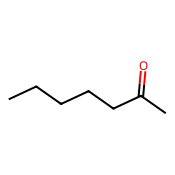

In [93]:
# ------------------------------------------------------------
# Function: molecule_name_to_image
# Purpose : Convert a molecule name into an RDKit image
# Inputs  : name        -> Common/IUPAC molecule name (str)
#           out_file    -> Output image file path (str)
#           size        -> Image size as (width, height) tuple
# Output  : Saves molecule image to disk and returns RDKit Mol
# Notes   : Requires pubchempy and RDKit
#           Uses PubChem to resolve the name into a SMILES string
# ------------------------------------------------------------

from rdkit import Chem
from rdkit.Chem import Draw
import pubchempy as pcp


def molecule_name_to_image(name: str, out_file: str = "molecule.png", size: tuple = (175, 175)):
    """
    Convert a molecule name into an RDKit-rendered image.

    Parameters
    ----------
    name : str
        Molecule name (common or IUPAC).
    out_file : str
        Path to save the output PNG image.
    size : tuple
        Image size in pixels, e.g. (500, 500).

    Returns
    -------
    mol : rdkit.Chem.Mol
        RDKit molecule object if successful.

    Raises
    ------
    ValueError
        If the molecule name cannot be resolved or parsed.
    """

    compounds = pcp.get_compounds(name, "name")
    if not compounds:
        raise ValueError(f"Could not find molecule name: {name}")

    smiles = compounds[0].canonical_smiles
    if not smiles:
        raise ValueError(f"No SMILES found for molecule: {name}")

    mol = Chem.MolFromSmiles(smiles)
    # mol_H = Chem.AddHs(mol)
    if mol is None:
        raise ValueError(f"RDKit could not parse SMILES: {smiles}")

    img = Draw.MolToImage(mol, size=size)
    # img.save(out_file)
    # img.show()

    print(f"Saved image for '{name}' to: {out_file}")
    print(f"Resolved SMILES: {smiles}")

    return mol, img


# Example usage
if __name__ == "__main__":
    _, img = molecule_name_to_image("heptanone") 

img